In [15]:
# make an array of all *.csv files in the current directory
import glob
import os
csv_files = glob.glob("prueba03*.csv")
csv_files.sort(key=os.path.getctime)
print(csv_files[:5])  # print the first 5 files
nfiles = len(csv_files)
print(f"Total CSV files found: {nfiles}")

['prueba03-1_20250901-140713.csv', 'prueba03-1_20250901-141407.csv', 'prueba03-3_20250901-142948.csv', 'prueba03-4_20250901-144023.csv', 'prueba03-4_20250901-144312.csv']
Total CSV files found: 33


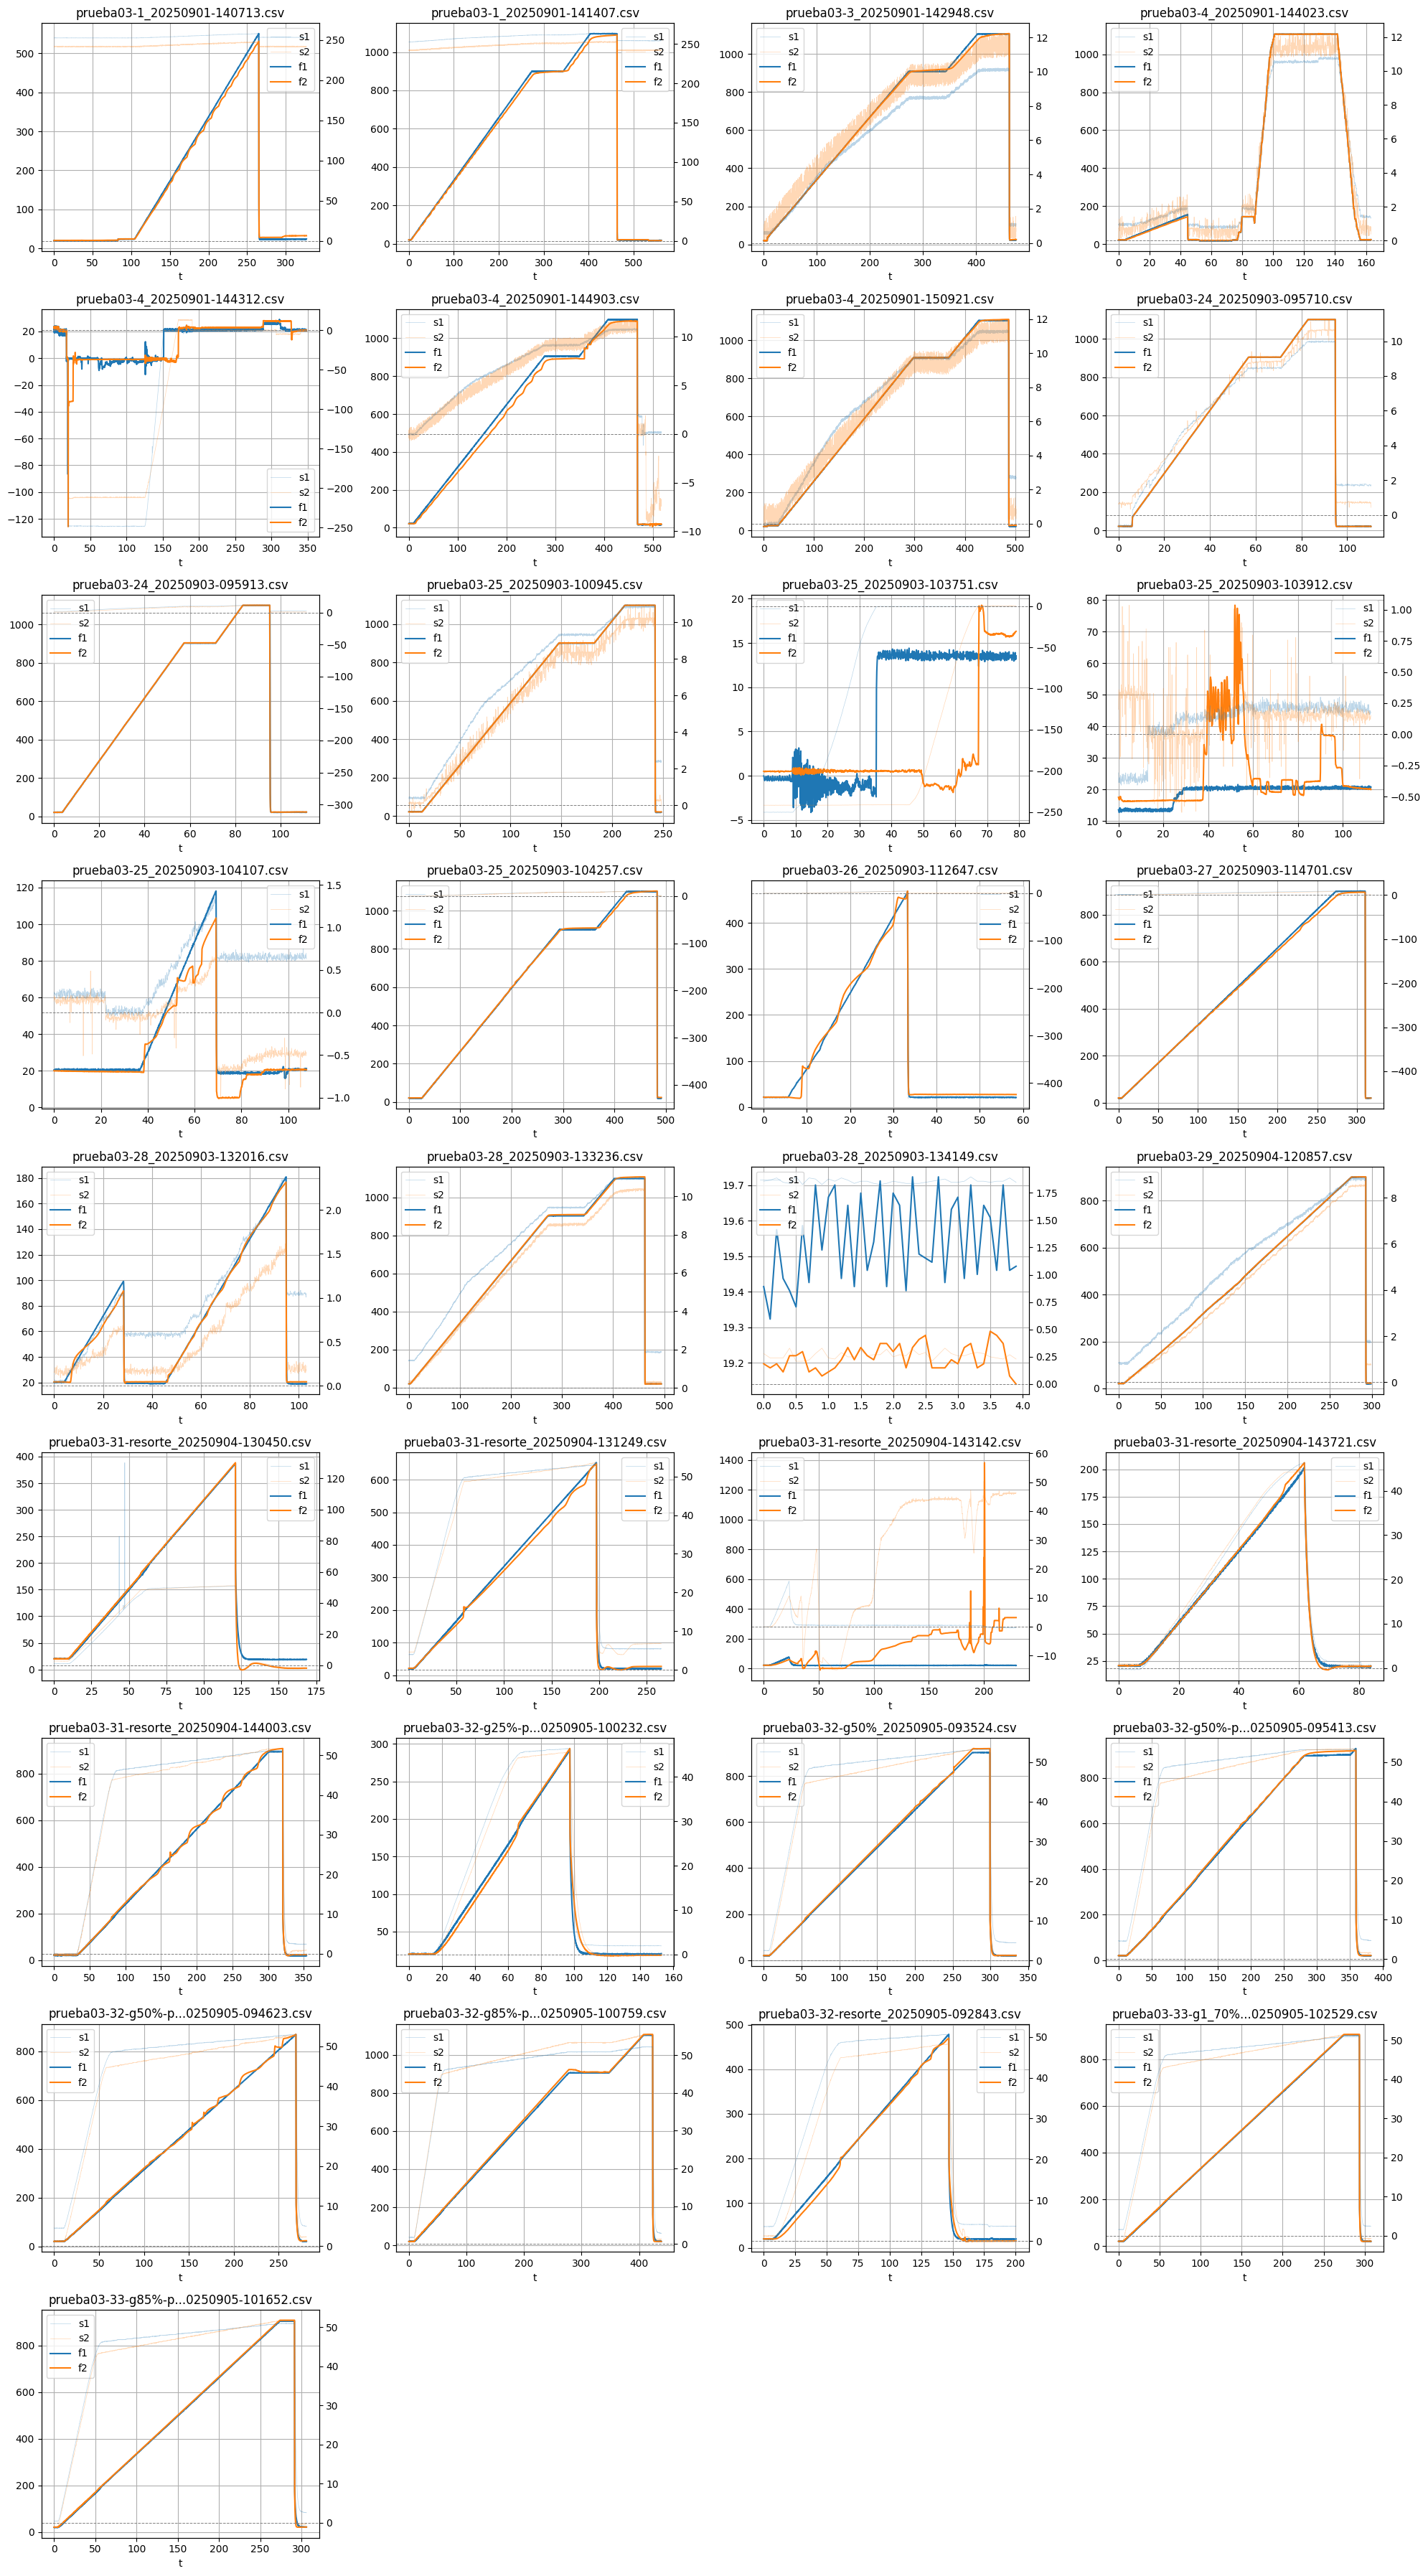

In [16]:

# make n x m subplots for the first n*m csv files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

m = 4
n = int(np.ceil(nfiles / m))

avoid_cols = ['0.100', 'Sample#', 's0L', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 'x1', 'x2', 'Mark#', 't']
right_y_axis = ['s1', 's2']

sratio = 10  # Samples per second

fig, axs = plt.subplots(n, m, figsize=(20, 4*n))
for i in range(n):
    for j in range(m):
        index = i * m + j
        if index < len(csv_files):
            ax1 = axs[i, j]
            data = pd.read_csv(csv_files[index], header=0, sep='\t')

            data['t'] = data.index / sratio
            
            # Create a secondary y-axis that shares the same x-axis
            ax2 = ax1.twinx()
            
            y_cols = [col for col in data.columns if col not in avoid_cols]
            
            lines, labels = [], []
            
            for col in y_cols:
                plot_data = data[[col, 't']].dropna()
                if not plot_data.empty:
                    if col in right_y_axis:
                        # Plot on the right axis (ax2)
                        line, = ax2.plot(plot_data['t'], plot_data[col], label=col, linewidth=0.5, alpha=0.3)
                    else:
                        # Plot on the left axis (ax1)
                        line, = ax1.plot(plot_data['t'], plot_data[col], label=col)
                    lines.append(line)
                    labels.append(col)
            
            # Shorten the title if it's too long to fit nicely
            title = csv_files[index]
            max_len = 40 # max length of the title
            if len(title) > max_len:
                half_len = (max_len - 3) // 2
                title = title[:half_len] + "..." + title[-half_len:]
            ax1.set_title(title)
            ax1.set_xlabel('t')
            
            # Create a single legend for both axes
            ax2.axhline(0, color='gray', linewidth=0.7, linestyle='--')
            ax1.legend(lines, labels, loc='best')
            ax1.grid(True)
            ax2.grid(False)


# Hide any unused subplots
for k in range(len(csv_files), n * m):
    fig.delaxes(axs.flatten()[k])


# Add vertical space between subplots
fig.subplots_adjust(hspace=0.4)
# Add horizontal space between subplots
fig.subplots_adjust(wspace=0.3)

# save plot to disk
plt.savefig('panorama_plots.png', dpi=300, bbox_inches='tight')

plt.tight_layout()